## 核心思想
贪心算法在每一步选择当前看起来最优的决策，跳过对所有可能方案的枚举。与动态规划不同，贪心不保存子问题的结果，而是一路向前、永不回头。贪心的正确性依赖问题具备贪心选择性质，即局部最优能够导向全局最优，这通常通过交换论证来证明：假设存在一个非贪心的最优解，通过"交换"使其变得更贪心，并证明交换后不会变差。

区间类问题：这是贪心的重要应用领域。以区间调度（选出最多不重叠区间）为例，贪心策略是按结束时间排序，每次选结束最早且不与已选区间重叠的区间。直觉是：结束越早，给后续区间留下的空间越大。这类"排序后扫描"的模式是贪心题的高频套路——排序本身就是在建立贪心决策的优先级。

贪心与 DP 的边界：两者都涉及最优化，但 DP 通过穷举所有子问题状态来保证全局最优，贪心通过局部最优跳过穷举。对于同一道题，如果能找到贪心选择性质，贪心往往比 DP 更高效。跳跃游戏（LC 55）既可以用 DP 做 O(n²)，也可以用贪心做 O(n)——贪心关键观察是：只需维护当前能到达的最远位置，不需要知道具体从哪里跳过来。

## 121. 买卖股票的最佳时机

给定一个数组 prices ，它的第 i 个元素 prices[i] 表示一支给定股票第 i 天的价格。

你只能选择 某一天 买入这只股票，并选择在 未来的某一个不同的日子 卖出该股票。设计一个算法来计算你所能获取的最大利润。

返回你可以从这笔交易中获取的最大利润。如果你不能获取任何利润，返回 0 。

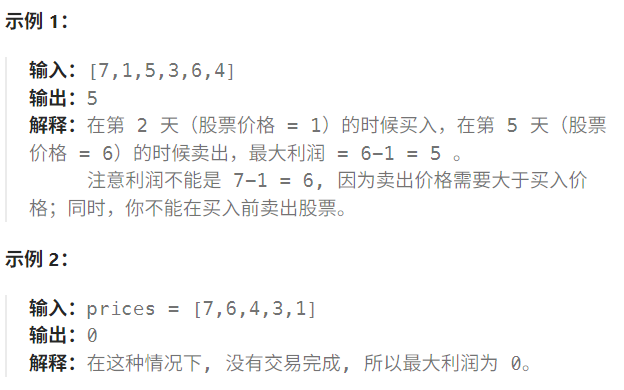

In [11]:
class Solution:
    def maxProfit(self, prices) -> int:
        n = len(prices)
        cur_min_price = prices[0]
        max_profit = 0
        for i in range(1, n):
            cur_min_price = min(cur_min_price, prices[i])
            max_profit = max(max_profit, prices[i] - cur_min_price)
        return max_profit

## 55. 跳跃游戏

给你一个非负整数数组 nums ，你最初位于数组的 第一个下标 。数组中的每个元素代表你在该位置可以跳跃的最大长度。

判断你是否能够到达最后一个下标，如果可以，返回 true ；否则，返回 false 。

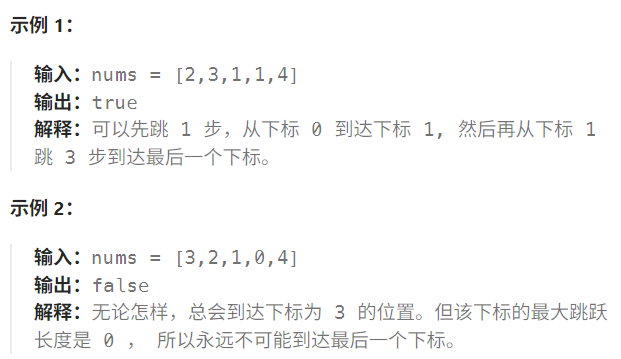

In [12]:
def canJump(self, nums) -> bool:
    max_reach = 0                        # 当前能到达的最远位置

    for i, jump in enumerate(nums):
        if i > max_reach:                # 当前位置已不可达，提前终止
            return False
        max_reach = max(max_reach, i + jump)

    return True


# **执行过程示例**：
# nums = [3, 2, 1, 0, 4]

# i=0: max_reach = 3
# i=1: max_reach = 3
# i=2: max_reach = 3
# i=3: max_reach = max(3, 3+0) = 3
# i=4: 4 > 3 → 返回 False ✅

**核心洞察**： 不需要记录每个位置是否可达，只需维护一个变量 max_reach——当前能到达的最远下标。

**本质原理**

DP 问题能转化为贪心的充要条件：后续状态只依赖于前驱状态的某个极值，而不需要完整的状态历史。
本题中，dp[i] = true 当且仅当 i ≤ max_reach，因此完整的布尔数组可被单个最大值变量完全替代。

---

## 45. 跳跃游戏 II

给定一个长度为 n 的 0 索引整数数组 nums。初始位置在下标 0。

每个元素 nums[i] 表示从索引 i 向后跳转的最大长度。换句话说，如果你在索引 i 处，你可以跳转到任意 (i + j) 处：

0 <= j <= nums[i] 且
i + j < n
返回到达 n - 1 的最小跳跃次数。测试用例保证可以到达 n - 1。

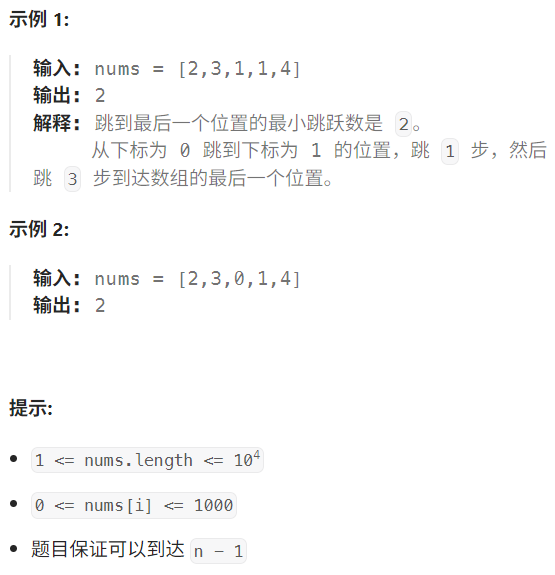

In [13]:
def jump(self, nums) -> int:
    jumps    = 0   # 已跳跃次数
    cur_end  = 0   # 当前层（本次跳跃）的边界
    max_reach = 0  # 下一层能到达的最远位置

    # 注意：i 只遍历到 n-2，到达 n-1 不需要再跳
    for i in range(len(nums) - 1):
        max_reach = max(max_reach, i + nums[i])  # 持续更新下一步最远

        if i == cur_end:          # 到达当前层边界，必须跳跃
            jumps   += 1
            cur_end  = max_reach  # 进入下一层

            if cur_end >= len(nums) - 1:  # 提前终止
                break

    return jumps

贪心地将数组按"跳跃次数"隐式分层，用 `cur_end` 标记当前层的右边界、`max_reach` 记录在当前层内能延伸到的最远位置，每次遍历到 `cur_end` 时触发一次跳跃并将 `cur_end` 推进到 `max_reach`——这样每一跳都保证覆盖范围最大化，直到 `cur_end` 超过终点为止，跳跃次数即为答案。

---

## 763. 划分字母区间

给你一个字符串 s 。我们要把这个字符串划分为尽可能多的片段，同一字母最多出现在一个片段中。例如，字符串 "ababcc" 能够被分为 ["abab", "cc"]，但类似 ["aba", "bcc"] 或 ["ab", "ab", "cc"] 的划分是非法的。

注意，划分结果需要满足：将所有划分结果按顺序连接，得到的字符串仍然是 s 。

返回一个表示每个字符串片段的长度的列表。

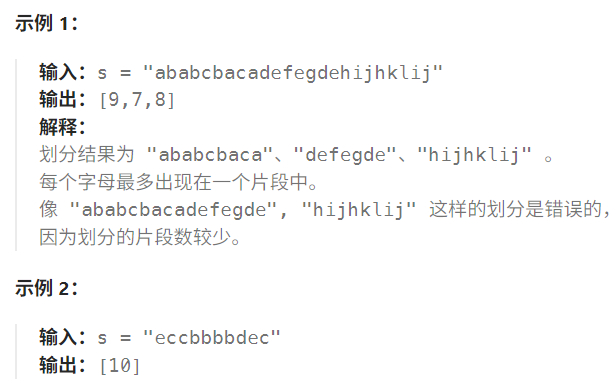

In [14]:
def partitionLabels(self, s: str):
    # Step 1：预处理每个字符最后出现的位置
    last = {c: i for i, c in enumerate(s)}

    result   = []
    cur_end  = 0   # 当前片段的右边界（必须包含到此）
    start    = 0   # 当前片段的起点

    for i, c in enumerate(s):
        cur_end = max(cur_end, last[c])   # 遇到新字符，边界可能右扩

        if i == cur_end:                  # 到达边界，切割
            result.append(i - start + 1)
            start = i + 1

    return result

# 执行过程追踪
# s = "ababcbacadefegdehijhklij"

# 预处理 last：a→8, b→5, c→7, d→14, e→15, f→11, g→13, h→19, i→22, j→23, k→20, l→21

# i=0  'a': cur_end=max(0,8)=8
# i=1  'b': cur_end=max(8,5)=8
# i=2  'a': cur_end=max(8,8)=8
# i=3  'b': cur_end=max(8,5)=8
# i=4  'c': cur_end=max(8,7)=8
# i=5  'b': cur_end=max(8,5)=8
# i=6  'a': cur_end=max(8,8)=8
# i=7  'c': cur_end=max(8,7)=8
# i=8  'a': cur_end=max(8,8)=8  → i==cur_end，切割！长度=8-0+1=9，start=9

# i=9  'd': cur_end=14
# i=10 'e': cur_end=15
# ...
# i=15 'e': cur_end=15          → i==cur_end，切割！长度=15-9+1=7，start=16

# i=16 'h': cur_end=19
# ...
# i=23 'j': cur_end=23          → i==cur_end，切割！长度=23-16+1=8，start=24

# 返回 [9, 7, 8] ✅

本题与跳跃游戏 II 是同一贪心框架的直接应用：预处理每个字符的最后出现位置，遍历时用 cur_end 标记当前片段必须延伸到的最远位置，到达 cur_end 时切割——每个片段都是能包含其中所有字符的最短区间。

跳跃游戏 II：cur_end = 当前层右边界，到达时强制跳跃（分层）
                          ↕ 同构
划分字母区间：cur_end = 当前片段必须延伸到的最远位置，到达时切割（分段）

为什么贪心正确？

当遍历到位置 i 时，cur_end 已经是"包含 [start..i] 中所有字符的最后出现位置"的最大值。若在 i < cur_end 处切割，则 [start..i] 中某字符还会在后续片段出现，违反题意。因此 i == cur_end 是最早合法切割点，贪心切割保证片段数最多。